<a href="https://colab.research.google.com/github/andysanchez1403-droid/ANDREA-GLZ-SNZ/blob/main/TAREA%20M%C3%89TODO_M%C3%8DNIMOS_CUADRADOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [59]:
# RESOLUCIÓN EJERCICIO 5.8

# Símbolos
x = sp.symbols('x', real=True)
a0, a1, a2, a3 = sp.symbols('a0 a1 a2 a3', real=True)

In [68]:
# APROXIMACIÓN POLINÓMICA: u_N = a0 + a1*x + a2*x^2 + a3*x^3
u_N = a0 + a1*x + a2*x**2 + a3*x**3

print("EJERCICIO 5.8: MÉTODO DE MÍNIMOS CUADRADOS")

print(f" Aproximación polinómica:")
print(f"   u_N(x) = {u_N}")


EJERCICIO 5.8: MÉTODO DE MÍNIMOS CUADRADOS
 Aproximación polinómica:
   u_N(x) = a0 + a1*x + a2*x**2 + a3*x**3


In [69]:
# APLICAR CONDICIONES INICIALES
print(f" Aplicar condiciones iniciales:")
print(f"   a) u(0) = 0")

# u(0) = a0 = 0
condicion1 = sp.Eq(a0, 0)
print(f"      a0 = 0")

print(f"   b) u'(0) = 2")
# u'(x) = a1 + 2*a2*x + 3*a3*x^2
# u'(0) = a1 = 2
condicion2 = sp.Eq(a1, 2)
print(f"      a1 = 2")

# Sustituir condiciones en u_N
u_N_cond = u_N.subs({a0: 0, a1: 2})
print(f"   u_N(x) con condiciones aplicadas:")
print(f"   u_N(x) = {u_N_cond}")

# Parámetros libres: a2, a3

 Aplicar condiciones iniciales:
   a) u(0) = 0
      a0 = 0
   b) u'(0) = 2
      a1 = 2
   u_N(x) con condiciones aplicadas:
   u_N(x) = a2*x**2 + a3*x**3 + 2*x


In [70]:
# CALCULAMOS RESIDUO R(x) = u_N'' + u_N - x
print(f" Residuo de la EDO:")
print(f"   R(x) = u_N'' + u_N - x")

# Segunda derivada
u_N_segunda = sp.diff(u_N_cond, x, 2)
print(f"   u_N''(x) = {u_N_segunda}")

# Residuo
R = u_N_segunda + u_N_cond - x
print(f"   R(x) = {sp.simplify(R)}")


 Residuo de la EDO:
   R(x) = u_N'' + u_N - x
   u_N''(x) = 2*(a2 + 3*a3*x)
   R(x) = a2*x**2 + 2*a2 + a3*x**3 + 6*a3*x + x


Ahora si aplicamos el **MÉTODO DE LOS MÍNIMOS CUADRADOS**

In [71]:
print(f" Método de mínimos cuadrados:")
print(f"   Minimizar J(a2, a3) = ∫₀¹ [R(x)]² dx")

# Definir el funcional J
J = sp.integrate(R**2, (x, 0, 1))
J_simpl = sp.simplify(J)
print(f"   J(a2, a3) = {J_simpl}")

 Método de mínimos cuadrados:
   Minimizar J(a2, a3) = ∫₀¹ [R(x)]² dx
   J(a2, a3) = 83*a2**2/15 + 49*a2*a3/3 + 5*a2/2 + 509*a3**2/35 + 22*a3/5 + 1/3


In [72]:
# Creamos el sistema de ecuaciones.

print(f" Sistema de ecuaciones:")

# Derivadas parciales
dJ_da2 = sp.diff(J_simpl, a2)
dJ_da3 = sp.diff(J_simpl, a3)

print(f"   ∂J/∂a2 = {sp.simplify(dJ_da2)} = 0")
print(f"   ∂J/∂a3 = {sp.simplify(dJ_da3)} = 0")

# Resolver el sistema
sistema = [
    sp.Eq(dJ_da2, 0),
    sp.Eq(dJ_da3, 0)
]

solucion = sp.solve(sistema, (a2, a3), dict=True)
print(f"   Solución del sistema:")

# Extraer valores
a2_val = solucion[0][a2]
a3_val = solucion[0][a3]

print(f"   a2 = {a2_val}")
print(f"   a3 = {a3_val}")


 Sistema de ecuaciones:
   ∂J/∂a2 = 166*a2/15 + 49*a3/3 + 5/2 = 0
   ∂J/∂a3 = 49*a2/3 + 1018*a3/35 + 22/5 = 0
   Solución del sistema:
   a2 = -1335/86789
   a3 = -24759/173578


In [73]:
#  Sustituir todos los coeficientes
u_N_final = u_N_cond.subs({a2: a2_val, a3: a3_val})
print(f" Solución aproximada final:")
print(f"   u_N(x) = {sp.expand(u_N_final)}")

 Solución aproximada final:
   u_N(x) = -24759*x**3/173578 - 1335*x**2/86789 + 2*x


In [65]:


# Resolver la EDO exactamente
u = sp.Function('u')
ode = sp.Eq(sp.diff(u(x), x, 2) + u(x), x)
condiciones = {u(0): 0, sp.diff(u(x), x).subs(x, 0): 2}
sol_exacta = sp.dsolve(ode, u(x), ics=condiciones)
u_exacta = sol_exacta.rhs

print(f"   u(x) = {sp.simplify(u_exacta)}")

   u(x) = x + sin(x)


In [74]:
print(f" Comparación gráfica:")

# Convertir a funciones numéricas
u_aprox_num = sp.lambdify(x, u_N_final, 'numpy')
u_exacta_num = sp.lambdify(x, u_exacta, 'numpy')

# Evaluar en [0, 1]
x_vals = np.linspace(0, 1, 100)
y_aprox = u_aprox_num(x_vals)
y_exact = u_exacta_num(x_vals)

# Error
error = np.abs(y_exact - y_aprox)
error_max = np.max(error)

print(f"   Error máximo en [0, 1]: {error_max:.6e}")

 Comparación gráfica:
   Error máximo en [0, 1]: 1.100971e-03


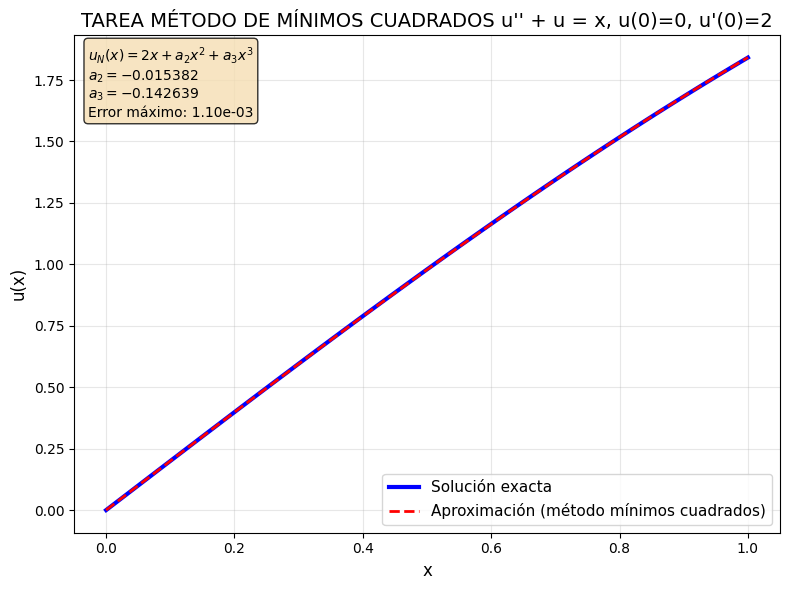

In [58]:
# GRÁFICA

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_exact, 'b-', linewidth=3, label='Solución exacta')
plt.plot(x_vals, y_aprox, 'r--', linewidth=2, label='Aproximación (método mínimos cuadrados)')
plt.xlabel('x', fontsize=12)
plt.ylabel('u(x)', fontsize=12)
plt.title('TAREA MÉTODO DE MÍNIMOS CUADRADOS u\'\' + u = x, u(0)=0, u\'(0)=2', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

# Mostrar coeficientes en la gráfica
textstr = '\n'.join((
    r'$u_N(x) = 2x + a_2x^2 + a_3x^3$',
    r'$a_2 = %.6f$' % a2_val,
    r'$a_3 = %.6f$' % a3_val,
    r'Error máximo: %.2e' % error_max
))
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.show()


In [54]:
print(f"Aproximación: u_N(x) = {sp.expand(u_N_final)}")
print(f"Solución exacta: u(x) = {sp.simplify(u_exacta)}")
print(f"Error máximo en [0,1]: {error_max:.6e}")

Aproximación: u_N(x) = -24759*x**3/173578 - 1335*x**2/86789 + 2*x
Solución exacta: u(x) = x + sin(x)
Error máximo en [0,1]: 1.100971e-03
